# 💼 Singapore Job Market Analysis: Predicting Hard-to-Fill Roles
## Stage 1: Exploratory Data Analysis & Cleaning Quality Audit

This notebook presents an end-to-end analysis of Singapore job market data (`SGJobData.csv`), auditing data cleaning steps, visualising hard-to-fill role metrics, and integrating with an interactive Streamlit dashboard.

### Step 1.1: Dataset Ingestion & Initial Schema Audit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings('ignore')

# Load raw dataset
df_raw = pd.read_csv('data/SGJobData.csv')

print("=" * 60)
print("📌 BEFORE CLEANING: Raw Dataset Dimensions & Structure")
print("=" * 60)
print(f"Total Raw Postings: {len(df_raw):,} rows x {len(df_raw.columns)} columns")
display(df_raw[['categories', 'employmentTypes', 'metadata_originalPostingDate', 'salary_minimum', 'salary_maximum', 'status_jobStatus']].head(3))
print(df_raw.info(verbose=False, memory_usage='deep'))

📌 BEFORE CLEANING: Raw Dataset Dimensions & Structure
Total Raw Postings: 1,048,585 rows x 22 columns


,categories,employmentTypes,metadata_originalPostingDate,salary_minimum,salary_maximum,status_jobStatus
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-03-30,2000,2800,Closed
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-04-08,4000,5500,Closed
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-08,3800,4600,Closed


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048585 entries, 0 to 1048584
Columns: 22 entries, categories to average_salary
dtypes: bool(1), float64(2), int64(8), object(11)
memory usage: 921.3 MB
None


### Step 1.2: Auditing & Dropping Uninformative Empty Columns

In [2]:
print("📌 BEFORE CHANGE: occupationId non-null count:", df_raw['occupationId'].notna().sum())
print(f"Total Columns Before: {len(df_raw.columns)}")

# Drop uninformative empty column
df_step2 = df_raw.drop(columns=['occupationId'], errors='ignore')

print("\n" + "=" * 60)
print("📌 AFTER CHANGE: Uninformative Column Removed")
print("=" * 60)
print("Is 'occupationId' present in columns?", 'occupationId' in df_step2.columns)
print(f"Total Columns After: {len(df_step2.columns)}")

📌 BEFORE CHANGE: occupationId non-null count: 0
Total Columns Before: 22

📌 AFTER CHANGE: Uninformative Column Removed
Is 'occupationId' present in columns? False
Total Columns After: 21


### Step 1.3: Category JSON Extraction via Fail-Safe Regex

In [3]:
def extract_category_regex(cat_str):
    if pd.isna(cat_str) or not isinstance(cat_str, str):
        return np.nan
    match = re.search(r'["\']category["\']\s*:\s*["\']([^"\']+)["\']', cat_str)
    return match.group(1) if match else np.nan

df_step3 = df_step2.copy()
df_step3['clean_category'] = df_step3['categories'].apply(extract_category_regex)

print("📌 AFTER EXTRACTION: Clean Category Column Populated")
display(df_step3[['categories', 'clean_category']].head(4))

📌 AFTER EXTRACTION: Clean Category Column Populated


,categories,clean_category
0,"[{""id"":13,""category"":""Environment / Health""},{...",Environment / Health
1,"[{""id"":21,""category"":""Information Technology""}]",Information Technology
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Repair and Maintenance
3,"[{""id"":21,""category"":""Information Technology""}]",Information Technology


### Step 1.4: Date Conversion & Active Posting Duration Calculation

In [4]:
df_step4 = df_step3.copy()
df_step4['orig_posting_dt'] = pd.to_datetime(df_step4['metadata_originalPostingDate'], errors='coerce')
df_step4['expiry_dt'] = pd.to_datetime(df_step4['metadata_expiryDate'], errors='coerce')
df_step4['posting_duration_days'] = (df_step4['expiry_dt'] - df_step4['orig_posting_dt']).dt.days.fillna(0)

print("📌 AFTER CONVERSION: Datetime Converted & 'posting_duration_days' Created")
display(df_step4[['metadata_originalPostingDate', 'metadata_expiryDate', 'posting_duration_days']].head(4))

📌 AFTER CONVERSION: Datetime Converted & 'posting_duration_days' Created


,metadata_originalPostingDate,metadata_expiryDate,posting_duration_days
0,2023-03-30,2023-05-08,39.0
1,2023-04-08,2023-05-08,30.0
2,2023-04-08,2023-04-22,14.0
3,2023-04-08,2023-05-08,30.0


### Step 1.5: Filtering Open Job Postings & Standard Monthly Employment Types

In [5]:
valid_emp_types = ['Permanent', 'Full Time', 'Contract', 'Internship/Attachment']
df_step5 = df_step4[
    (df_step4['status_jobStatus'] == 'Open') &
    (df_step4['employmentTypes'].isin(valid_emp_types))
].copy()

print(f"Total Rows Retained: {len(df_step5):,}")

Total Rows Retained: 861,729


### Step 1.6: Constructing Composite Role Difficulty Index

In [6]:
df_final_clean = df_step5.copy()
df_final_clean['metadata_repostCount'] = pd.to_numeric(df_final_clean['metadata_repostCount'], errors='coerce').fillna(0)
df_final_clean['posting_duration_days'] = pd.to_numeric(df_final_clean['posting_duration_days'], errors='coerce').fillna(0)
df_final_clean['difficulty_score'] = (df_final_clean['metadata_repostCount'] + 1) * (df_final_clean['posting_duration_days'] + 1)

print("📌 AFTER METRIC CREATION: 'difficulty_score' Computed")
display(df_final_clean[['title', 'clean_category', 'metadata_repostCount', 'posting_duration_days', 'difficulty_score']].head(5))

📌 AFTER METRIC CREATION: 'difficulty_score' Computed


,title,clean_category,metadata_repostCount,posting_duration_days,difficulty_score
123069,Preschool Educator,Education and Training,0,30.0,31.0
123070,Risk Analyst,Others,0,30.0,31.0
123071,Operations Executive (Corporate Action),Accounting / Auditing / Taxation,0,30.0,31.0
123072,Logistics Officer - Contract Logistics/SCM,Logistics / Supply Chain,0,30.0,31.0
123073,"Business Analyst (Agile, Waterfall)",Information Technology,0,30.0,31.0


## Stage 2: Class Presentation Visualizations

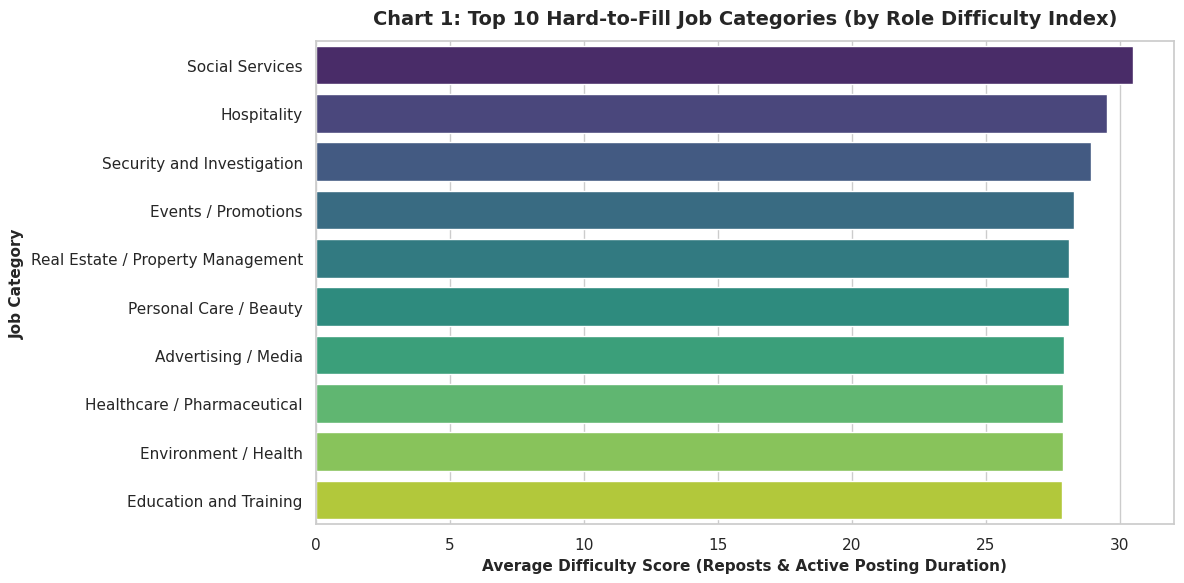

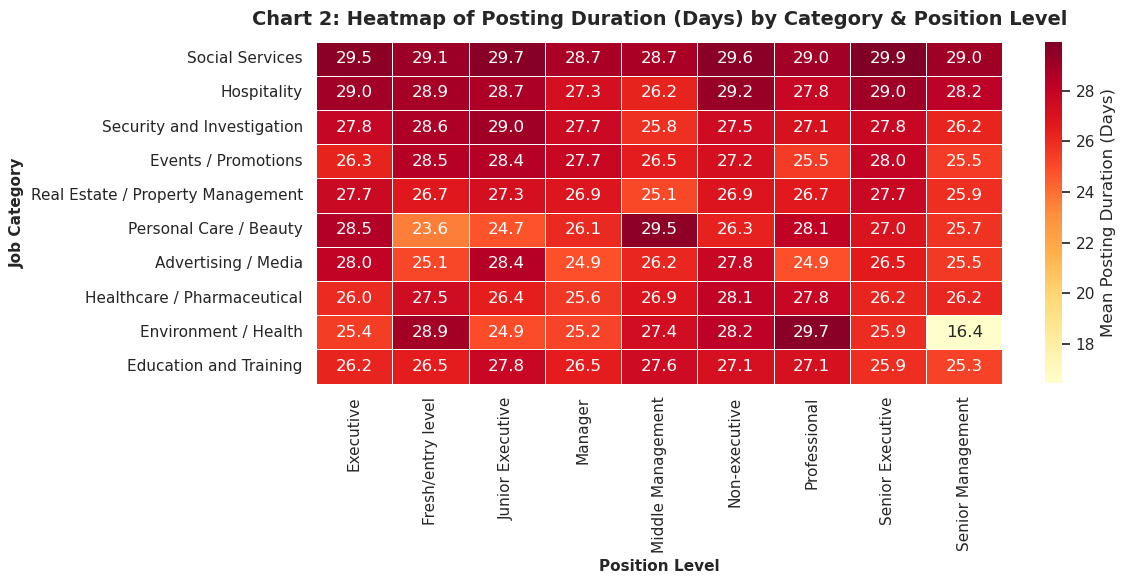

<Figure size 1200x600 with 0 Axes>

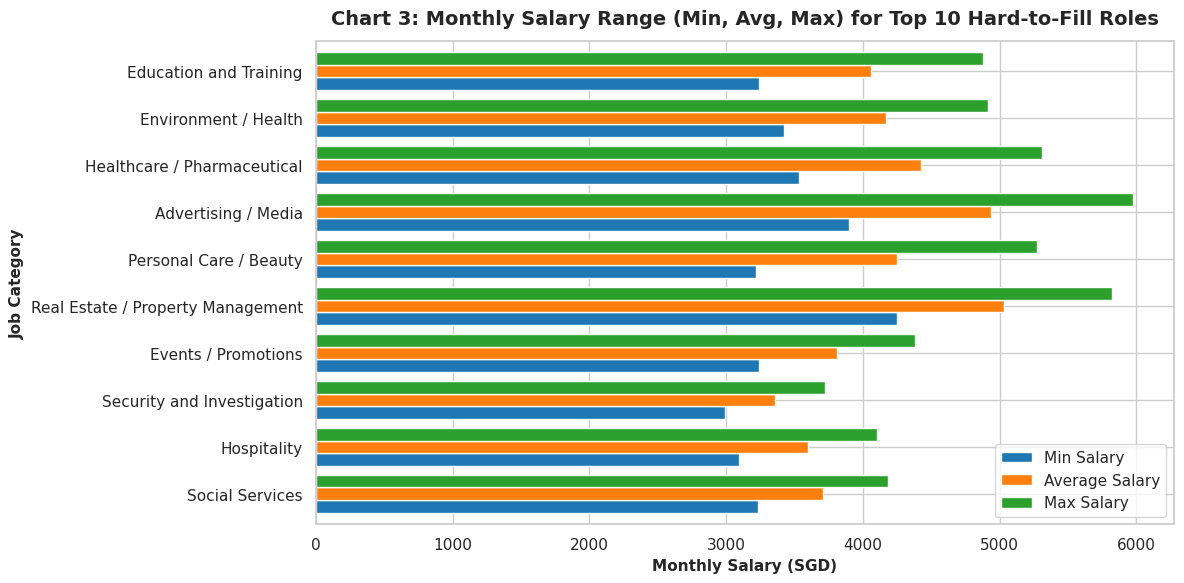

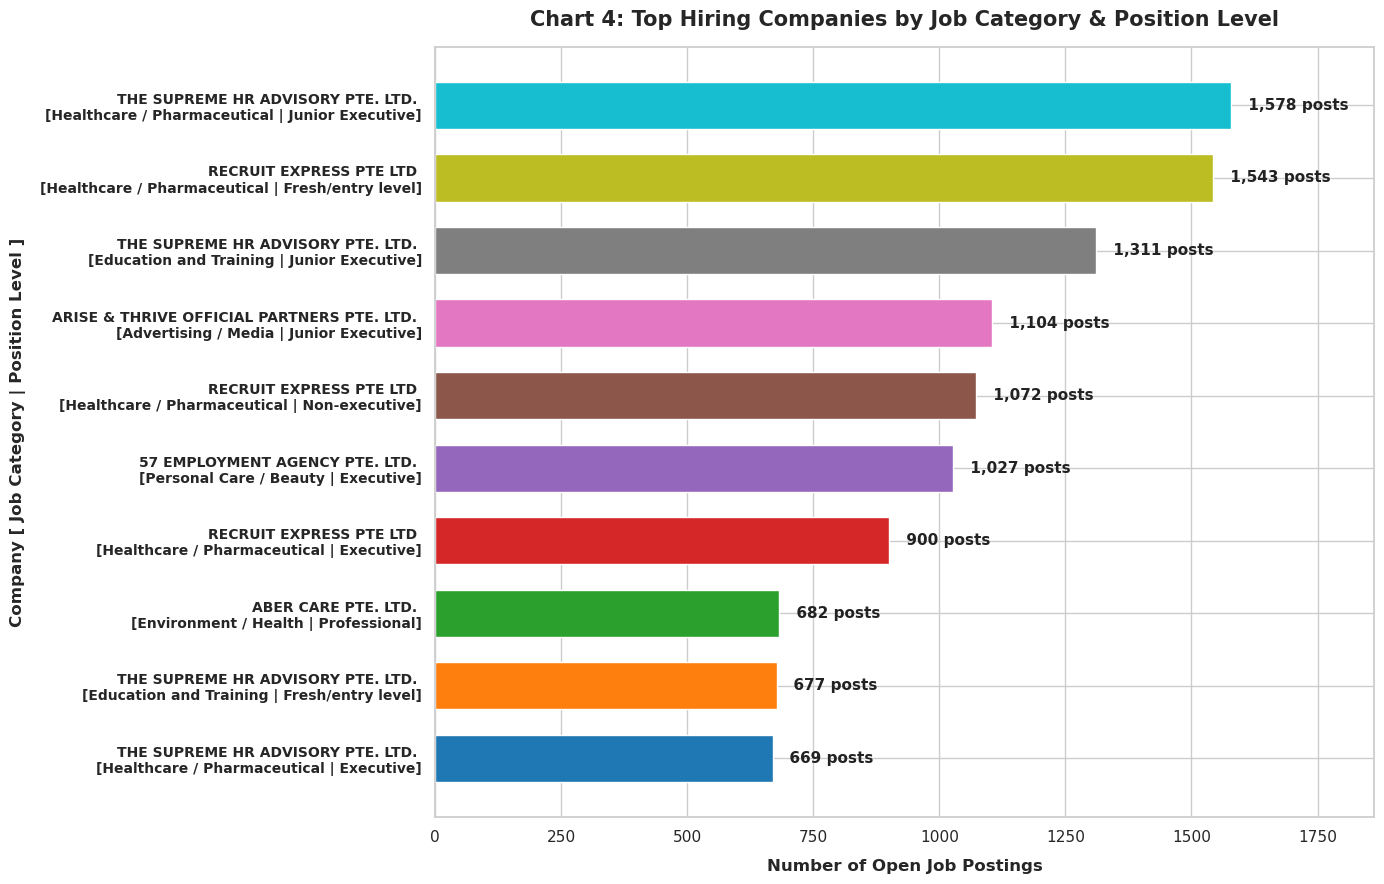

In [7]:
sns.set_theme(style="whitegrid")
df_stage2 = df_final_clean.dropna(subset=['clean_category', 'positionLevels']).copy()
cat_difficulty = df_stage2.groupby('clean_category')['difficulty_score'].mean().sort_values(ascending=False)
top10_categories = cat_difficulty.head(10).index.tolist()
df_top10 = df_stage2[df_stage2['clean_category'].isin(top10_categories)].copy()

# Chart 1: Top 10 Hard-to-Fill Roles
plt.figure(figsize=(12, 6))
chart1_data = df_top10.groupby('clean_category')['difficulty_score'].mean().loc[top10_categories].reset_index()
sns.barplot(data=chart1_data, y='clean_category', x='difficulty_score', palette='viridis')
plt.title('Chart 1: Top 10 Hard-to-Fill Job Categories (by Role Difficulty Index)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Average Difficulty Score (Reposts & Active Posting Duration)', fontsize=11, fontweight='bold')
plt.ylabel('Job Category', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Chart 2: Posting Duration Heatmap
plt.figure(figsize=(12, 6))
pivot_duration = df_top10.pivot_table(index='clean_category', columns='positionLevels', values='posting_duration_days', aggfunc='mean', fill_value=0).reindex(top10_categories)
sns.heatmap(pivot_duration, annot=True, fmt=".1f", cmap='YlOrRd', cbar_kws={'label': 'Mean Posting Duration (Days)'}, linewidths=0.5)
plt.title('Chart 2: Heatmap of Posting Duration (Days) by Category & Position Level', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Position Level', fontsize=11, fontweight='bold')
plt.ylabel('Job Category', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Chart 3: Monthly Salary Spectrum
plt.figure(figsize=(12, 6))
salary_summary = df_top10.groupby('clean_category')[['salary_minimum', 'average_salary', 'salary_maximum']].mean().reindex(top10_categories)
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
salary_summary.plot(kind='barh', figsize=(12, 6), color=custom_colors, width=0.8)
plt.title('Chart 3: Monthly Salary Range (Min, Avg, Max) for Top 10 Hard-to-Fill Roles', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Monthly Salary (SGD)', fontsize=11, fontweight='bold')
plt.ylabel('Job Category', fontsize=11, fontweight='bold')
plt.legend(['Min Salary', 'Average Salary', 'Max Salary'], loc='lower right')
plt.tight_layout()
plt.show()

# Chart 4: Top Hiring Companies
plt.figure(figsize=(14, 9))
comp_breakdown = (
    df_top10.groupby(['postedCompany_name', 'clean_category', 'positionLevels'])
    .size().reset_index(name='posting_count')
    .sort_values(by='posting_count', ascending=True).tail(10)
)
comp_breakdown['display_label'] = comp_breakdown['postedCompany_name'] + " \n[" + comp_breakdown['clean_category'] + " | " + comp_breakdown['positionLevels'] + "]"
colors = plt.cm.tab10.colors[:len(comp_breakdown)]
bars = plt.barh(y=comp_breakdown['display_label'], width=comp_breakdown['posting_count'], color=colors, height=0.65)
max_count = comp_breakdown['posting_count'].max()
for bar in bars:
    width = bar.get_width()
    plt.text(x=width + (max_count * 0.015), y=bar.get_y() + bar.get_height() / 2, s=f" {width:,} posts", va='center', ha='left', fontsize=11, fontweight='bold', color='#222222')
plt.xlim(0, max_count * 1.18)
plt.title('Chart 4: Top Hiring Companies by Job Category & Position Level', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Number of Open Job Postings', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Company [ Job Category | Position Level ]', fontsize=12, fontweight='bold', labelpad=10)
plt.yticks(fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Stage 3: Streamlit Interactive Dashboard Integration

Run `streamlit run app.py` to launch the interactive app.